In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('data_clean/cleaned_retail_sales.csv')

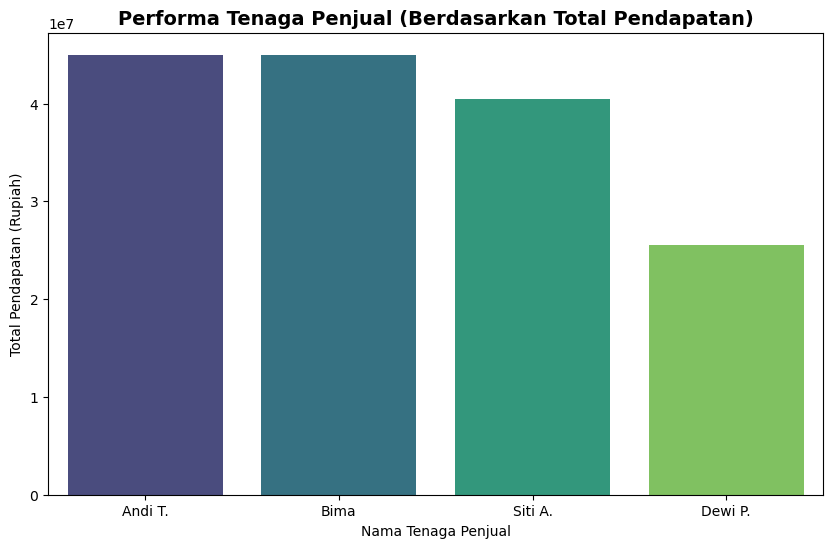

In [3]:
# Performa Tenaga Penjual
df_salesperson_valid = df[df['Salesperson'] != 'Unknown'] # Mengambil dan mengecek nilai kecuali 'Unknown'

# Mengelompokan nama 'Salesperson', lalu jumlahkan pendapatannya (Revenue)
sales_performance = df_salesperson_valid.groupby('Salesperson')['Revenue'].sum().reset_index()

# Mengurutkan dari pendapatan (Revenue) dengan descending (niai terbesar ke nilai terkecil)
sales_performance = sales_performance.sort_values(by='Revenue', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sales_performance,
    x='Salesperson',
    y='Revenue',
    hue='Salesperson',
    palette='viridis',     # Tema warna gradasi
    legend=False           # Sembunyikan legenda
)

plt.title('Performa Tenaga Penjual (Berdasarkan Total Pendapatan)', fontsize=14, fontweight='bold')
plt.xlabel('Nama Tenaga Penjual')
plt.ylabel('Total Pendapatan (Rupiah)')

plt.savefig(
    'performa_penjual.png',   # Nama file gambar
    dpi=300,                    # Resolusi gambar
    bbox_inches='tight'         # Memastikan tidak ada teks/label yang terpotong di pinggir gambar
)

plt.show()

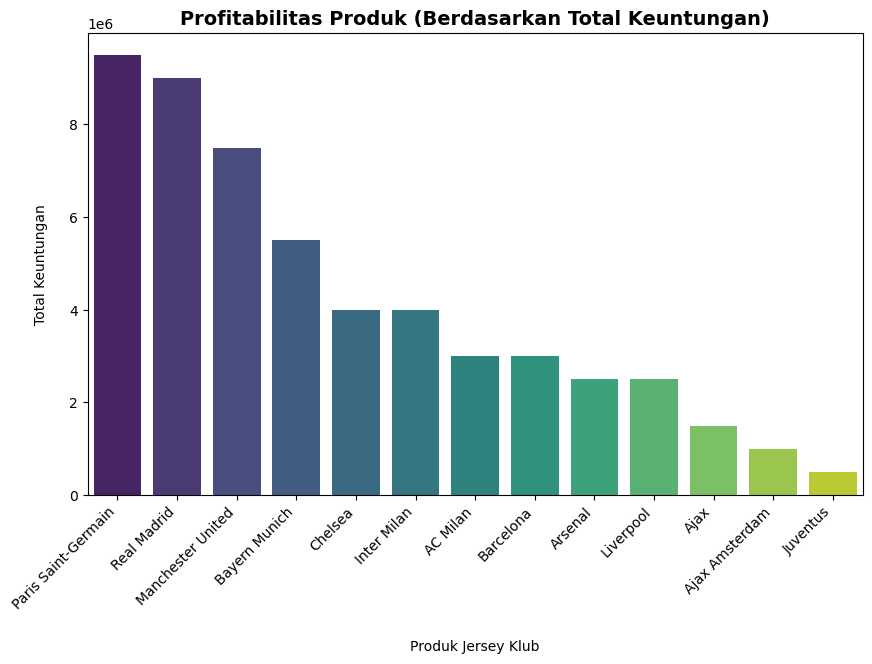

In [4]:
# Profitabilitas Produk
# Mengelompokan nama 'Product_Name', lalu jumlahkan keuntungannya (Total_Profit)
product_profitability = df.groupby('Product_Name')['Total_Profit'].sum().reset_index()

# Mengurutkan dari keuntungan (Total_Profit) dengan descending (niai terbesar ke nilai terkecil)
product_profitability = product_profitability.sort_values(by='Total_Profit', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_profitability,
    x='Product_Name',
    y='Total_Profit',
    hue='Product_Name',
    palette='viridis',
    legend=False
)

plt.title('Profitabilitas Produk (Berdasarkan Total Keuntungan)', fontsize=14, fontweight='bold') # Judul
plt.xlabel('Produk Jersey Klub', labelpad=20) # Judul pada sumbu x
plt.ylabel('Total Keuntungan', labelpad=15) # Judul pada sumbu y

plt.xticks(rotation=45, ha='right') # Memiringkan teks nama klub di sumbu X

plt.savefig(
    'profibilitas_produk.png',   # Nama file gambar
    dpi=300,                    # Resolusi gambar
    bbox_inches='tight'         # Memastikan tidak ada teks/label yang terpotong di pinggir gambar
)

plt.show()


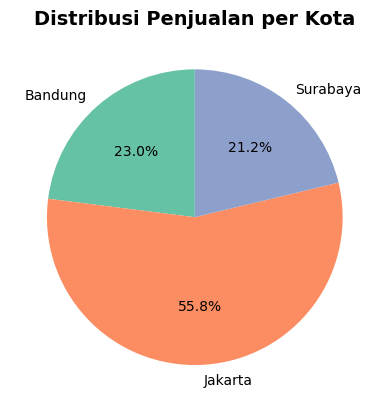

In [5]:
# Distribusi Penjualan per Kota
sales_distribution = df.groupby('Store_Location')['Revenue'].sum().reset_index()

# Palet warna untuk pie chart
pie_color = sns.color_palette('Set2')[0:len(sales_distribution)]

plt.pie(
    x='Revenue',
    data=sales_distribution,
    labels='Store_Location',
    autopct='%1.1f%%', # Angka persentase, 1f = 1 bilangan pecahan dibelakang koma
    startangle=90, # 90 derajat agar proporsional
    colors=pie_color
)

plt.title('Distribusi Penjualan per Kota', fontsize=14, fontweight='bold') # Judul

plt.savefig(
    'distribusi_penjualan.png',   # Nama file gambar
    dpi=300,                    # Resolusi gambar
    bbox_inches='tight'         # Memastikan tidak ada teks/label yang terpotong di pinggir gambar
)

plt.show()

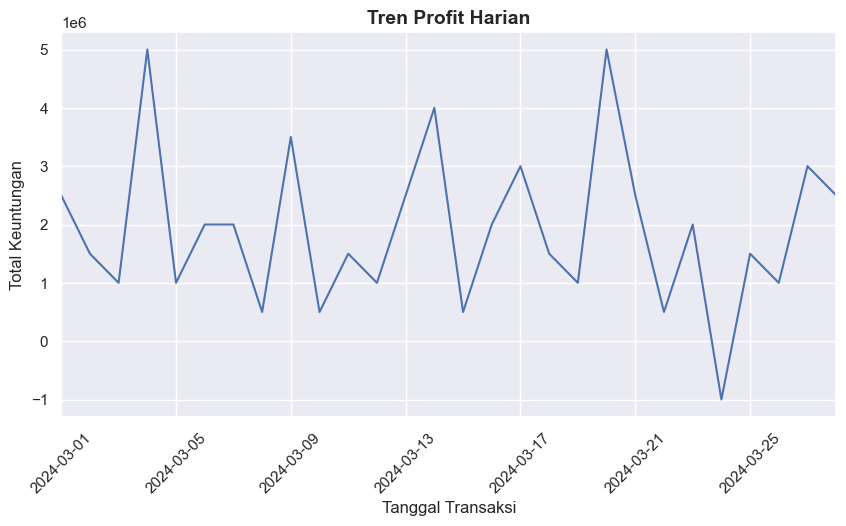

In [6]:
# Tren Profit Harian
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
daily_tren = df.groupby('Transaction_Date')['Total_Profit'].sum().reset_index()

plt.figure(figsize=(10, 5))

sns.set_theme(style='darkgrid') # Tema gelap

sns.lineplot(
    data=daily_tren,
    x='Transaction_Date',
    y='Total_Profit'
)

plt.title('Tren Profit Harian', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal Transaksi')
plt.ylabel('Total Keuntungan')

plt.xticks(rotation=45)

# Membatasi sumbu X agar pas dari tanggal awal sampai tanggal akhir di data
plt.xlim(daily_tren['Transaction_Date'].min(), daily_tren['Transaction_Date'].max())

plt.savefig(
    'profit_harian.png',   # Nama file gambar
    dpi=300,                    # Resolusi gambar
    bbox_inches='tight'         # Memastikan tidak ada teks/label yang terpotong di pinggir gambar
)

plt.show()